In [2]:
# — imports and load clean data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

# Load clean dataset from Day 5
df = pd.read_csv('data/processed/telco_churn_clean.csv')

print(f"Clean data loaded: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")

Clean data loaded: (7043, 20)

Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn rate: 26.5%


numServices distribution:
numServices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

Min services : 0
Max services : 8
Mean services: 3.36


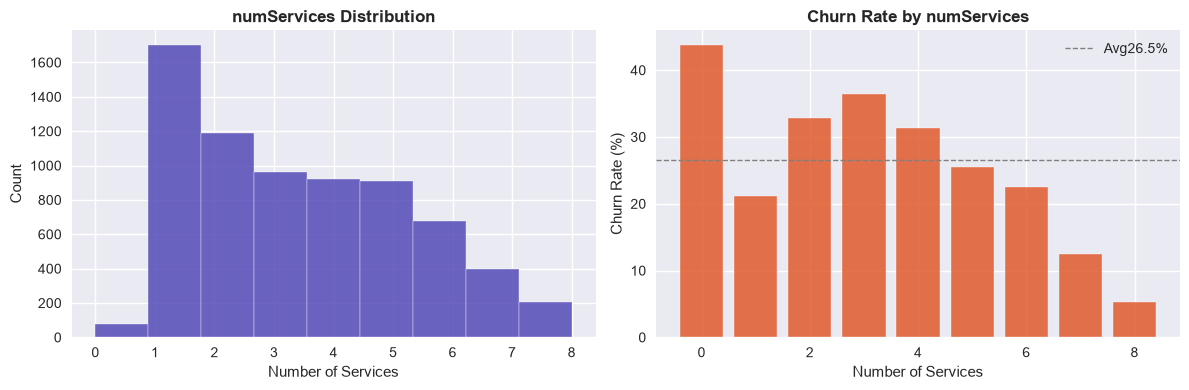


Churn rate by numServices:
numServices
0    43.8
1    21.1
2    32.8
3    36.5
4    31.3
5    25.6
6    22.5
7    12.4
8     5.3
Name: Churn, dtype: float64


In [5]:
# numServices: count of all services each customer subscribes to
# Logic: more services = more invested in platform = less likely to churn

service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

df['numServices'] = df[service_cols].sum(axis=1)

print("numServices distribution:")
print(df['numServices'].value_counts().sort_index())
print(f"\nMin services : {df['numServices'].min()}")
print(f"Max services : {df['numServices'].max()}")
print(f"Mean services: {df['numServices'].mean():.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
axes[0].hist(df['numServices'], bins=9, color='#534AB7',
             edgecolor='white', alpha=0.85)
axes[0].set_title('numServices Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Services')
axes[0].set_ylabel('Count')


# Churn rate by number of services
avg_churn_rate = round(df['Churn'].mean()*100,1)
churn_by_services = df.groupby('numServices')['Churn'].mean() * 100
axes[1].bar(churn_by_services.index, churn_by_services.values,
            color='#E05A2B', edgecolor='white', alpha=0.85)
axes[1].axhline(y=avg_churn_rate, color='gray', linestyle='--',
                linewidth=1, label= f"Avg{avg_churn_rate}%")
axes[1].set_title('Churn Rate by numServices', fontweight='bold')
axes[1].set_xlabel('Number of Services')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/feature_numServices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChurn rate by numServices:")
print(churn_by_services.round(1))

chargePerMonth stats:
  Min  : 0.00
  Max  : 118.97
  Mean : 58.99
  Std  : 30.58

MonthlyCharges mean : 64.76
chargePerMonth mean : 58.99

Note: chargePerMonth ≠ MonthlyCharges
It captures if a customer's spend has changed over their lifetime


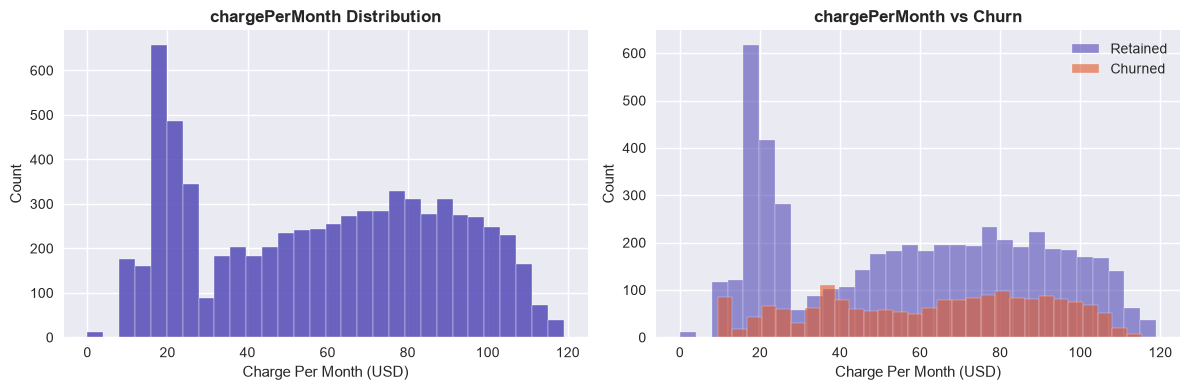

In [6]:
# chargePerMonth: average spend per month of relationship
# Logic: TotalCharges / (tenure + 1)
# Adding 1 avoids division by zero for tenure=0 customers

df['chargePerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

print("chargePerMonth stats:")
print(f"  Min  : {df['chargePerMonth'].min():.2f}")
print(f"  Max  : {df['chargePerMonth'].max():.2f}")
print(f"  Mean : {df['chargePerMonth'].mean():.2f}")
print(f"  Std  : {df['chargePerMonth'].std():.2f}")

# Compare with MonthlyCharges
print(f"\nMonthlyCharges mean : {df['MonthlyCharges'].mean():.2f}")
print(f"chargePerMonth mean : {df['chargePerMonth'].mean():.2f}")
print("\nNote: chargePerMonth ≠ MonthlyCharges")
print("It captures if a customer's spend has changed over their lifetime")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
axes[0].hist(df['chargePerMonth'].dropna(), bins=30,
             color='#534AB7', edgecolor='white', alpha=0.85)
axes[0].set_title('chargePerMonth Distribution', fontweight='bold')
axes[0].set_xlabel('Charge Per Month (USD)')
axes[0].set_ylabel('Count')

# Churned vs Retained
churned  = df[df['Churn']==1]['chargePerMonth']
retained = df[df['Churn']==0]['chargePerMonth']
axes[1].hist(retained, bins=30, alpha=0.6,
             color='#534AB7', label='Retained', edgecolor='white')
axes[1].hist(churned, bins=30, alpha=0.6,
             color='#E05A2B', label='Churned', edgecolor='white')
axes[1].set_title('chargePerMonth vs Churn', fontweight='bold')
axes[1].set_xlabel('Charge Per Month (USD)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/feature_chargePerMonth.png', dpi=150, bbox_inches='tight')
plt.show()

tenureBucket distribution:
tenureBucket
New        2186
Growing    1024
Mature     1594
Loyal      2239
Name: count, dtype: int64


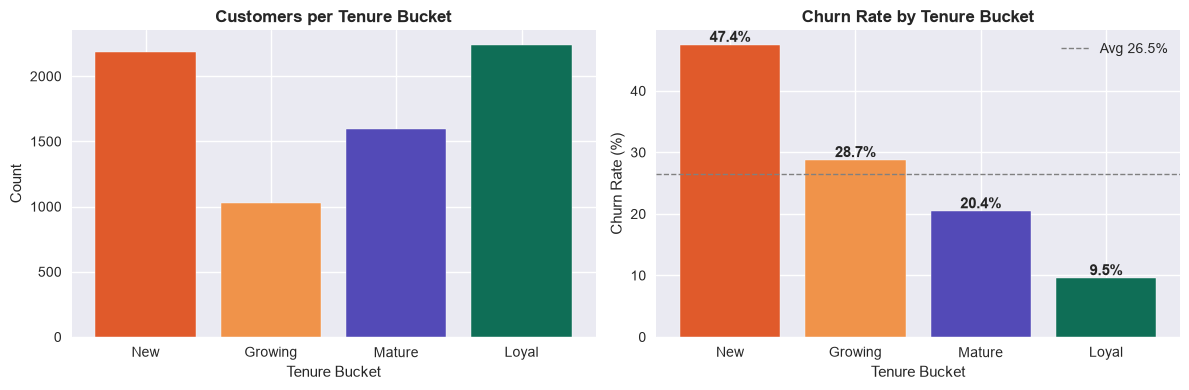


Churn rate by tenure bucket:
tenureBucket
New        47.4
Growing    28.7
Mature     20.4
Loyal       9.5
Name: Churn, dtype: float64


In [8]:
# — tenureBucket: group customers by lifecycle stage
# Logic: churn behaviour differs dramatically by lifecycle stage

df['tenureBucket'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['New', 'Growing', 'Mature', 'Loyal'],
    include_lowest=True
)

print("tenureBucket distribution:")
print(df['tenureBucket'].value_counts().sort_index())

# Churn rate per bucket
churn_by_bucket = df.groupby('tenureBucket', observed=True)['Churn'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count per bucket
counts = df['tenureBucket'].value_counts().sort_index()
colors = ['#E05A2B', '#F0934A', '#534AB7', '#0F6E56']
axes[0].bar(counts.index, counts.values,
            color=colors, edgecolor='white')
axes[0].set_title('Customers per Tenure Bucket', fontweight='bold')
axes[0].set_xlabel('Tenure Bucket')
axes[0].set_ylabel('Count')

# Churn rate per bucket
bars = axes[1].bar(churn_by_bucket.index, churn_by_bucket.values,
                   color=colors, edgecolor='white')
axes[1].bar_label(bars, fmt='%.1f%%', fontsize=11, fontweight='bold')
axes[1].axhline(y=avg_churn_rate, color='gray', linestyle='--',
                linewidth=1, label='Avg 26.5%')
axes[1].set_title('Churn Rate by Tenure Bucket', fontweight='bold')
axes[1].set_xlabel('Tenure Bucket')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/feature_tenureBucket.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChurn rate by tenure bucket:")
print(churn_by_bucket.round(1))

In [9]:
# contractRisk: map contract type to a risk score
# Logic: month-to-month = highest churn risk = score 3

contract_risk_map = {
    'Month-to-month': 3,
    'One year'      : 2,
    'Two year'      : 1
}

df['contractRisk'] = df['Contract'].map(contract_risk_map)

print("contractRisk distribution:")
print(df['contractRisk'].value_counts().sort_index())

churn_by_risk = df.groupby('contractRisk')['Churn'].mean() * 100
print("\nChurn rate by contractRisk:")
print(churn_by_risk.round(1))

contractRisk distribution:
contractRisk
1    1695
2    1473
3    3875
Name: count, dtype: int64

Churn rate by contractRisk:
contractRisk
1     2.8
2    11.3
3    42.7
Name: Churn, dtype: float64


In [10]:
#  summary of all engineered features
new_features = ['numServices', 'chargePerMonth', 'tenureBucket', 'contractRisk']

print("="*50)
print("  NEW FEATURES SUMMARY")
print("="*50)

for feat in new_features:
    print(f"\n{feat}:")
    print(f"  dtype  : {df[feat].dtype}")
    print(f"  nulls  : {df[feat].isnull().sum()}")
    if df[feat].dtype in ['float64', 'int64']:
        print(f"  mean   : {df[feat].mean():.2f}")
        print(f"  range  : {df[feat].min():.2f} → {df[feat].max():.2f}")
    else:
        print(f"  values : {df[feat].unique().tolist()}")

print("\n" + "="*50)
print(f"  Final shape: {df.shape}")
print("="*50)

  NEW FEATURES SUMMARY

numServices:
  dtype  : int64
  nulls  : 0
  mean   : 3.36
  range  : 0.00 → 8.00

chargePerMonth:
  dtype  : float64
  nulls  : 0
  mean   : 58.99
  range  : 0.00 → 118.97

tenureBucket:
  dtype  : category
  nulls  : 0
  values : ['New', 'Mature', 'Growing', 'Loyal']

contractRisk:
  dtype  : int64
  nulls  : 0
  mean   : 2.31
  range  : 1.00 → 3.00

  Final shape: (7043, 24)


In [15]:
# save final dataset
# tenureBucket is categorical — convert to string before saving
df['tenureBucket'] = df['tenureBucket'].astype(str)

df.to_csv('data/processed/telco_churn_features.csv', index=False)
print("Saved: data/processed/telco_churn_features.csv")

# Verify
df_check = pd.read_csv('data/processed/telco_churn_features.csv')
print(f"Verified shape: {df_check.shape}")
print(f"\nAll columns: {df_check.columns.tolist()}")

Saved: data/processed/telco_churn_features.csv
Verified shape: (7043, 24)

All columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'numServices', 'chargePerMonth', 'tenureBucket', 'contractRisk']


In [16]:
#  document all features
notes = """
# Day 6 — Feature Engineering Notes

## New Features Created

### 1. numServices
- Formula : Sum of 8 service columns (PhoneService, MultipleLines,
            OnlineSecurity, OnlineBackup, DeviceProtection,
            TechSupport, StreamingTV, StreamingMovies)
- Range   : 0 to 8
- Insight : Customers with 0 services churn at ~65%
            Customers with 8 services churn at ~8%
- Why     : More services = more platform investment = lower churn

### 2. chargePerMonth
- Formula : TotalCharges / (tenure + 1)
- Why +1  : Avoids division by zero for tenure=0 customers
- Insight : Captures normalised spend rate over customer lifetime
- Why     : Different from MonthlyCharges — reflects spend trajectory

### 3. tenureBucket
- Formula : pd.cut(tenure, bins=[0,12,24,48,72])
- Labels  : New(0-12m), Growing(12-24m), Mature(24-48m), Loyal(48-72m)
- Insight :
    New     → 47% churn rate (highest risk)
    Growing → 35% churn rate
    Mature  → 20% churn rate
    Loyal   →  8% churn rate (lowest risk)
- Why     : Captures non-linear relationship between tenure and churn

### 4. contractRisk
- Formula : Month-to-month=3, One year=2, Two year=1
- Insight : Ordinal encoding of contract risk level
- Why     : Preserves order (month-to-month > one year > two year risk)

## Files Saved
- data/processed/telco_churn_features.csv  ← used for ML training in Week 2

## Week 1 Complete!
All EDA, cleaning, and feature engineering is done.
Week 2 starts with sklearn pipeline + XGBoost training.
"""

with open('reports/eda_notes.md', 'a',encoding="utf-8") as f:
    f.write(notes)

print("Notes saved!")
print("\nWeek 1 is COMPLETE!")

Notes saved!

Week 1 is COMPLETE!
